In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


# Mall Customer Segmentation — PM Analysis
## Project goal
Segment mall customers by income and spending behaviour.
Discover natural customer groups the marketing team can act on.

## Key PM question
How many distinct customer types exist — and what strategy fits each?

In [2]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

# Rename columns for clarity
df.columns = ['customer_id', 'gender', 'age', 'annual_income', 'spending_score']

print("=== DATASET OVERVIEW ===")
print(f"Total customers: {len(df)}")
print(f"Columns: {list(df.columns)}")

print("\n=== BASIC STATS ===")
print(df[['age','annual_income','spending_score']].describe().round(1))

print("\n=== GENDER SPLIT ===")
print(df['gender'].value_counts())

print("\n=== FIRST 5 ROWS ===")
print(df.head())

=== DATASET OVERVIEW ===
Total customers: 200
Columns: ['customer_id', 'gender', 'age', 'annual_income', 'spending_score']

=== BASIC STATS ===
         age  annual_income  spending_score
count  200.0          200.0           200.0
mean    38.8           60.6            50.2
std     14.0           26.3            25.8
min     18.0           15.0             1.0
25%     28.8           41.5            34.8
50%     36.0           61.5            50.0
75%     49.0           78.0            73.0
max     70.0          137.0            99.0

=== GENDER SPLIT ===
gender
Female    112
Male       88
Name: count, dtype: int64

=== FIRST 5 ROWS ===
   customer_id  gender  age  annual_income  spending_score
0            1    Male   19             15              39
1            2    Male   21             15              81
2            3  Female   20             16               6
3            4  Female   23             16              77
4            5  Female   31             17              40


## Step 2 — Finding the right number of clusters (Elbow Method)

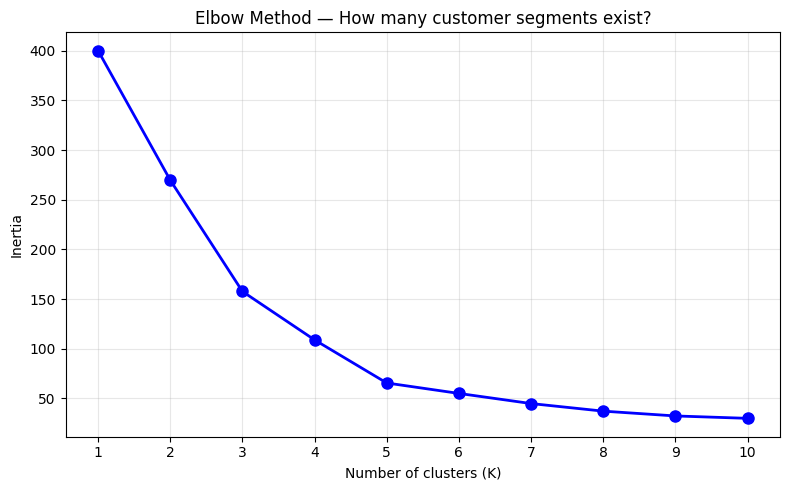

Inertia at each K:
  K=1: 400.0
  K=2: 269.7
  K=3: 157.7
  K=4: 108.9
  K=5: 65.6
  K=6: 55.1
  K=7: 44.9
  K=8: 37.2
  K=9: 32.4
  K=10: 30.0


In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

X = df[['annual_income', 'spending_score']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — How many customer segments exist?')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print("Inertia at each K:")
for k, val in zip(K_range, inertia):
    print(f"  K={k}: {val:.1f}")

=== 5 CUSTOMER SEGMENTS ===
         count  avg_age  avg_income  avg_spending
segment                                          
2           22     25.3        25.7          79.4
4           23     45.2        26.3          20.9
0           81     42.7        55.3          49.5
1           39     32.7        86.5          82.1
3           35     41.1        88.2          17.1


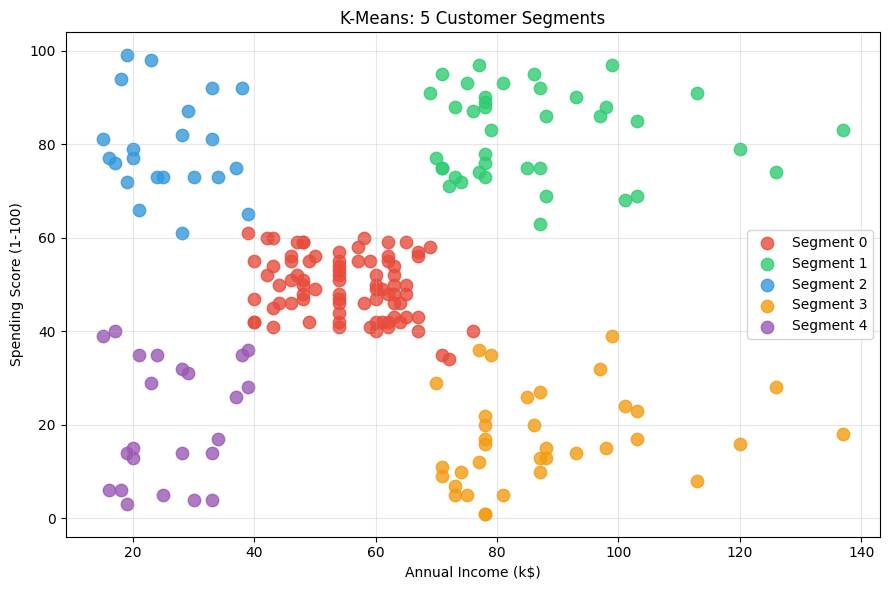

In [4]:
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['segment'] = km5.fit_predict(X_scaled)

print("=== 5 CUSTOMER SEGMENTS ===")
profile = df.groupby('segment').agg(
    count         = ('customer_id',    'count'),
    avg_age       = ('age',            'mean'),
    avg_income    = ('annual_income',  'mean'),
    avg_spending  = ('spending_score', 'mean')
).round(1)
print(profile.sort_values('avg_income'))

# Visualise
colors = ['#e74c3c','#2ecc71','#3498db','#f39c12','#9b59b6']
labels = ['Seg 0','Seg 1','Seg 2','Seg 3','Seg 4']

plt.figure(figsize=(9,6))
for i in range(5):
    mask = df['segment'] == i
    plt.scatter(df[mask]['annual_income'], df[mask]['spending_score'],
                c=colors[i], label=f'Segment {i}', s=80, alpha=0.8)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means: 5 Customer Segments')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans5.png', dpi=150, bbox_inches='tight')
plt.show()

=== QUADRANT PROFILES ===
                                 count  avg_age  avg_income  avg_spending
quadrant                                                                 
Q1: High Income + High Spending     50     35.0        81.7          76.2
Q2: High Income + Low Spending      50     40.9        81.5          24.8
Q3: Low Income + High Spending      52     34.8        39.6          65.2
Q4: Low Income + Low Spending       48     45.1        39.6          33.3

=== MARKETING STRATEGY PER SEGMENT ===

Q1: High Income + High Spending
  → RETAIN — VIP programme, loyalty rewards, exclusive previews

Q2: High Income + Low Spending
  → CONVERT — wrong product mix? Premium brands, personalised outreach

Q3: Low Income + High Spending
  → NURTURE — EMI offers, instalment plans, emotional loyalty

Q4: Low Income + Low Spending
  → DEPRIORITISE — focus on footfall, low marketing ROI


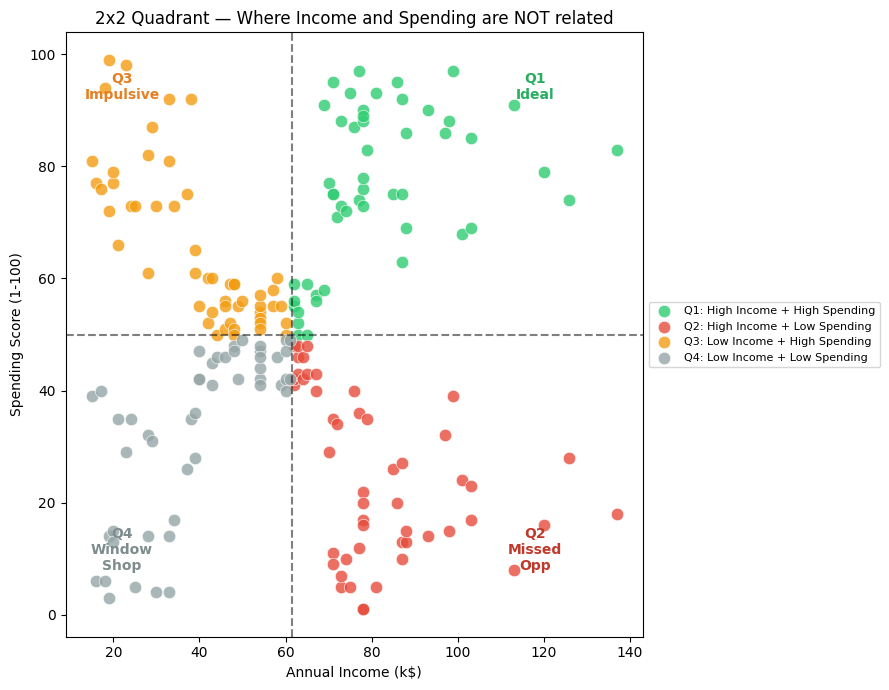


Income median: $61.5k | Spending median: 50.0


In [5]:
income_median   = df['annual_income'].median()
spending_median = df['spending_score'].median()

def assign_quadrant(row):
    hi = row['annual_income']  >= income_median
    hs = row['spending_score'] >= spending_median
    if hi and hs:     return 'Q1: High Income + High Spending'
    elif hi and not hs: return 'Q2: High Income + Low Spending'
    elif not hi and hs: return 'Q3: Low Income + High Spending'
    else:               return 'Q4: Low Income + Low Spending'

df['quadrant'] = df.apply(assign_quadrant, axis=1)

print("=== QUADRANT PROFILES ===")
print(df.groupby('quadrant').agg(
    count        = ('customer_id',    'count'),
    avg_age      = ('age',            'mean'),
    avg_income   = ('annual_income',  'mean'),
    avg_spending = ('spending_score', 'mean')
).round(1))

print("\n=== MARKETING STRATEGY PER SEGMENT ===")
strategies = {
    'Q1: High Income + High Spending':  'RETAIN — VIP programme, loyalty rewards, exclusive previews',
    'Q2: High Income + Low Spending':   'CONVERT — wrong product mix? Premium brands, personalised outreach',
    'Q3: Low Income + High Spending':   'NURTURE — EMI offers, instalment plans, emotional loyalty',
    'Q4: Low Income + Low Spending':    'DEPRIORITISE — focus on footfall, low marketing ROI'
}
for q, s in strategies.items():
    print(f"\n{q}")
    print(f"  → {s}")

# Plot
colors_q = {
    'Q1: High Income + High Spending': '#2ecc71',
    'Q2: High Income + Low Spending':  '#e74c3c',
    'Q3: Low Income + High Spending':  '#f39c12',
    'Q4: Low Income + Low Spending':   '#95a5a6'
}

plt.figure(figsize=(9,7))
for q, group in df.groupby('quadrant'):
    plt.scatter(group['annual_income'], group['spending_score'],
                c=colors_q[q], label=q, s=80, alpha=0.8,
                edgecolors='white', linewidth=0.5)

plt.axvline(x=income_median,   color='black', linestyle='--', alpha=0.5)
plt.axhline(y=spending_median, color='black', linestyle='--', alpha=0.5)
plt.text(118, 92, 'Q1\nIdeal',        fontsize=10, fontweight='bold', color='#27ae60', ha='center')
plt.text(118, 8,  'Q2\nMissed\nOpp',  fontsize=10, fontweight='bold', color='#c0392b', ha='center')
plt.text(22,  92, 'Q3\nImpulsive',    fontsize=10, fontweight='bold', color='#e67e22', ha='center')
plt.text(22,  8,  'Q4\nWindow\nShop', fontsize=10, fontweight='bold', color='#7f8c8d', ha='center')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('2x2 Quadrant — Where Income and Spending are NOT related')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.savefig('quadrant.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nIncome median: ${income_median}k | Spending median: {spending_median}")

## Step 3 — Quadrant Analysis findings

Q1 (High Income + High Spending): 50 customers — RETAIN
Q2 (High Income + Low Spending): 50 customers — CONVERT (biggest missed opportunity)
Q3 (Low Income + High Spending): 52 customers — NURTURE
Q4 (Low Income + Low Spending): 48 customers — DEPRIORITISE

Key insight: Q1 and Q2 have identical income ($81k) but opposite spending.
The gap is not financial — it is experiential. Wrong brands? Wrong stores?
This needs qualitative research, not more data.

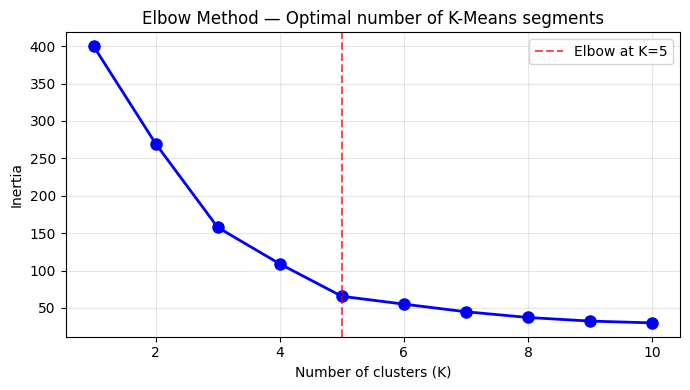

=== K-MEANS 5 SEGMENTS ===
                count  avg_age  avg_income  avg_spending
kmeans_segment                                          
2                  22     25.3        25.7          79.4
4                  23     45.2        26.3          20.9
0                  81     42.7        55.3          49.5
1                  39     32.7        86.5          82.1
3                  35     41.1        88.2          17.1


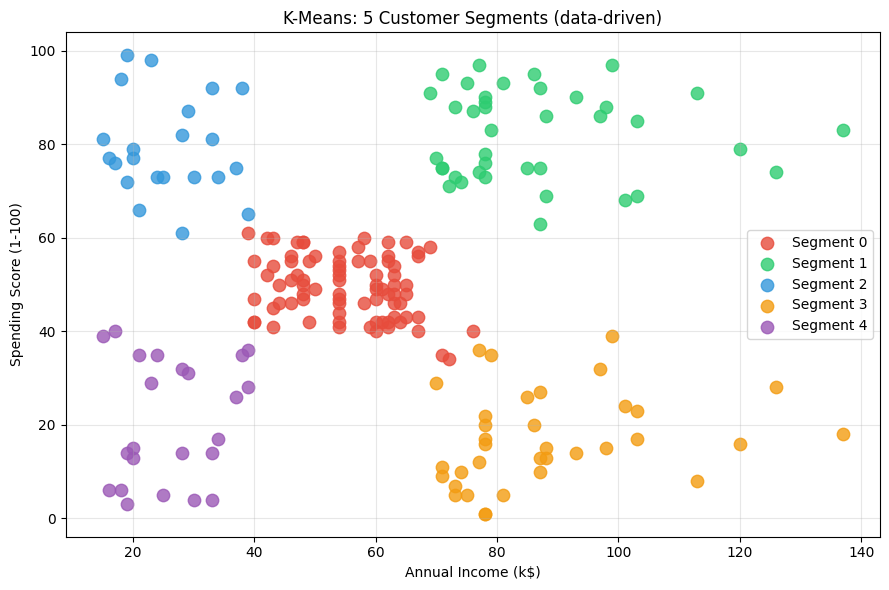


=== PM SEGMENT NAMES ===
Segment 2 → Young Impulsive Spenders | Income $25.7k | Spending 79.4
Segment 4 → Careful Low-Income | Income $26.3k | Spending 20.9
Segment 0 → Middle Ground | Income $55.3k | Spending 49.5
Segment 1 → High Value Customers | Income $86.5k | Spending 82.1
Segment 3 → Missed Opportunity | Income $88.2k | Spending 17.1


In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = df[['annual_income', 'spending_score']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal K using elbow
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot elbow
plt.figure(figsize=(7, 4))
plt.plot(range(1,11), inertia, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Elbow at K=5')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal number of K-Means segments')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow.png', dpi=150, bbox_inches='tight')
plt.show()

# Apply K=5
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['kmeans_segment'] = km5.fit_predict(X_scaled)

print("=== K-MEANS 5 SEGMENTS ===")
km_profile = df.groupby('kmeans_segment').agg(
    count        = ('customer_id',    'count'),
    avg_age      = ('age',            'mean'),
    avg_income   = ('annual_income',  'mean'),
    avg_spending = ('spending_score', 'mean')
).round(1).sort_values('avg_income')
print(km_profile)

# Plot K-Means
colors = ['#e74c3c','#2ecc71','#3498db','#f39c12','#9b59b6']
plt.figure(figsize=(9,6))
for i in range(5):
    mask = df['kmeans_segment'] == i
    plt.scatter(df[mask]['annual_income'], df[mask]['spending_score'],
                c=colors[i], label=f'Segment {i}', s=80, alpha=0.8)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means: 5 Customer Segments (data-driven)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans5.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== PM SEGMENT NAMES ===")
for idx, row in km_profile.iterrows():
    if row['avg_income'] < 40 and row['avg_spending'] < 40:
        name = "Careful Low-Income"
    elif row['avg_income'] < 40 and row['avg_spending'] > 60:
        name = "Young Impulsive Spenders"
    elif row['avg_income'] > 70 and row['avg_spending'] > 70:
        name = "High Value Customers"
    elif row['avg_income'] > 70 and row['avg_spending'] < 40:
        name = "Missed Opportunity"
    else:
        name = "Middle Ground"
    print(f"Segment {idx} → {name} | Income ${row['avg_income']}k | Spending {row['avg_spending']}")

GENDER ANALYSIS ACROSS ALL SEGMENTS

=== SPENDING BEHAVIOUR BY GENDER ===
        count  avg_age  avg_income  avg_spending
gender                                          
Female    112     38.1        59.2          51.5
Male       88     39.8        62.2          48.5

=== GENDER BY K-MEANS SEGMENT ===
gender                        name  Female  Male  pct_female  pct_male
kmeans_segment                                                        
0                    Middle Ground      48    33        59.3      40.7
1                       High Value      21    18        53.8      46.2
2                  Young Impulsive      13     9        59.1      40.9
3               Missed Opportunity      16    19        45.7      54.3
4               Careful Low-Income      14     9        60.9      39.1

=== GENDER BY QUADRANT ===
gender                           Female  Male  pct_female  pct_male
quadrant                                                           
Q1: High Income + High Spending   

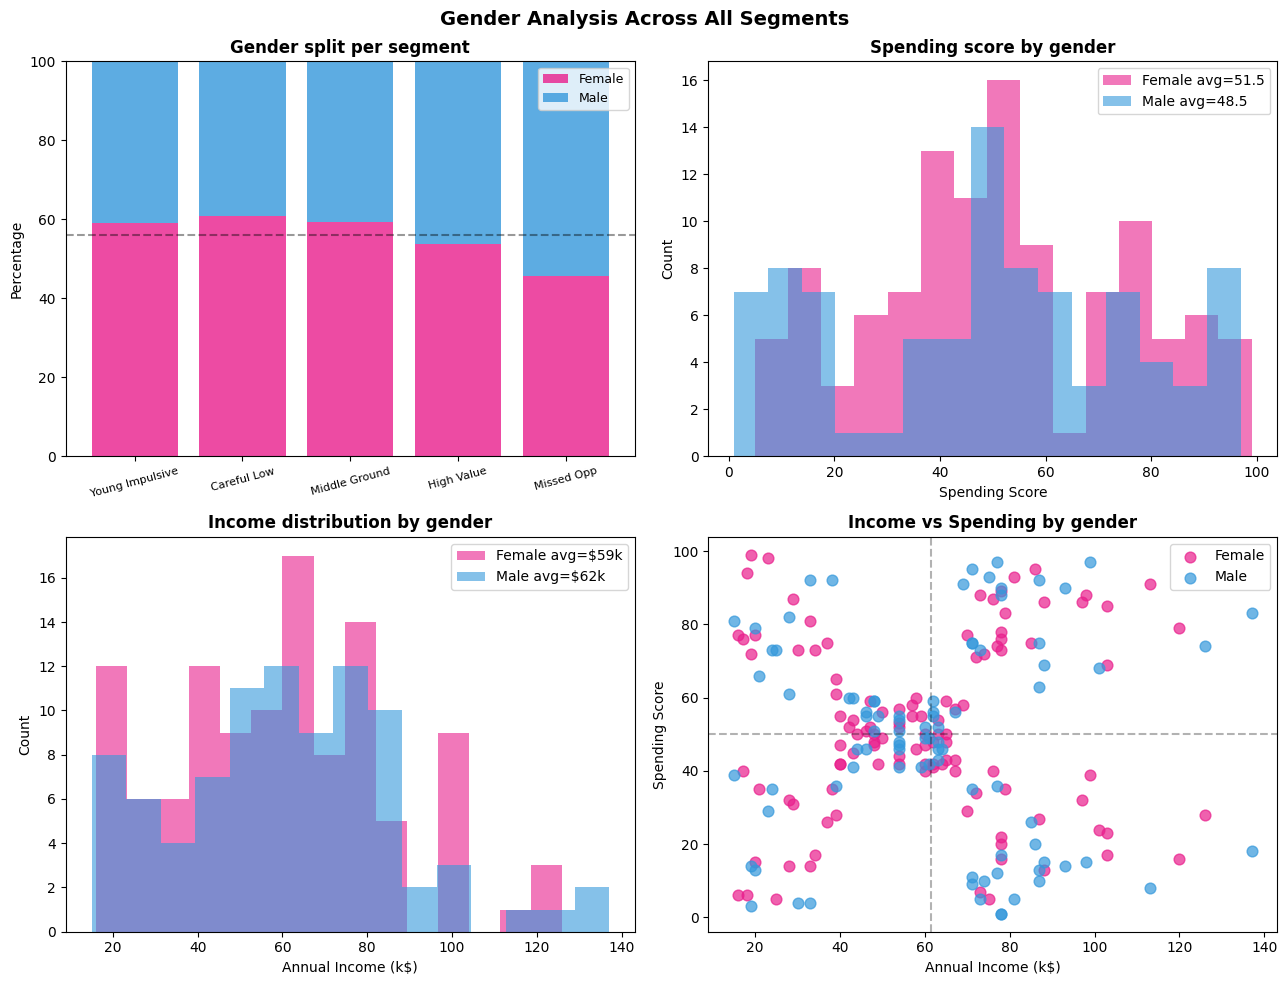

Done!


In [7]:
import matplotlib.pyplot as plt

print("="*55)
print("GENDER ANALYSIS ACROSS ALL SEGMENTS")
print("="*55)

# Overall gender stats
print("\n=== SPENDING BEHAVIOUR BY GENDER ===")
gender_stats = df.groupby('gender').agg(
    count        = ('customer_id',    'count'),
    avg_age      = ('age',            'mean'),
    avg_income   = ('annual_income',  'mean'),
    avg_spending = ('spending_score', 'mean')
).round(1)
print(gender_stats)

# Gender within K-Means segments
print("\n=== GENDER BY K-MEANS SEGMENT ===")
names = {0:'Middle Ground', 1:'High Value', 2:'Young Impulsive',
         3:'Missed Opportunity', 4:'Careful Low-Income'}
km_gender = df.groupby(['kmeans_segment','gender']).size().unstack(fill_value=0)
km_gender['total']      = km_gender.sum(axis=1)
km_gender['pct_female'] = (km_gender['Female']/km_gender['total']*100).round(1)
km_gender['pct_male']   = (km_gender['Male']/km_gender['total']*100).round(1)
km_gender['name']       = km_gender.index.map(names)
print(km_gender[['name','Female','Male','pct_female','pct_male']].to_string())

# Gender within quadrants
print("\n=== GENDER BY QUADRANT ===")
quad_gender = df.groupby(['quadrant','gender']).size().unstack(fill_value=0)
quad_gender['total']      = quad_gender.sum(axis=1)
quad_gender['pct_female'] = (quad_gender['Female']/quad_gender['total']*100).round(1)
quad_gender['pct_male']   = (quad_gender['Male']/quad_gender['total']*100).round(1)
print(quad_gender[['Female','Male','pct_female','pct_male']].to_string())

# High vs low spenders by gender
print("\n=== HIGH VS LOW SPENDERS BY GENDER ===")
for gender, total in [('Female', 112), ('Male', 88)]:
    high = ((df['gender']==gender) & (df['spending_score']>=50)).sum()
    low  = ((df['gender']==gender) & (df['spending_score']<50)).sum()
    print(f"{gender}: high spenders={high} ({high/total:.1%})  low spenders={low} ({low/total:.1%})")

# 4 charts
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Chart 1: Stacked bar — gender per segment
seg_order = [2, 4, 0, 1, 3]
seg_labels = ['Young Impulsive','Careful Low','Middle Ground','High Value','Missed Opp']
f_pcts = [km_gender.loc[s,'pct_female'] for s in seg_order]
m_pcts = [km_gender.loc[s,'pct_male']   for s in seg_order]
x = range(5)
axes[0,0].bar(x, f_pcts, label='Female', color='#e91e8c', alpha=0.8)
axes[0,0].bar(x, m_pcts, bottom=f_pcts, label='Male',   color='#3498db', alpha=0.8)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(seg_labels, fontsize=8, rotation=15)
axes[0,0].set_ylabel('Percentage')
axes[0,0].set_title('Gender split per segment', fontweight='bold')
axes[0,0].axhline(y=56, color='black', linestyle='--', alpha=0.4)
axes[0,0].legend(fontsize=9)
axes[0,0].set_ylim(0, 100)

# Chart 2: Spending score histogram
f_scores = df[df['gender']=='Female']['spending_score']
m_scores = df[df['gender']=='Male']['spending_score']
axes[0,1].hist(f_scores, bins=15, alpha=0.6, color='#e91e8c', label=f'Female avg={f_scores.mean():.1f}')
axes[0,1].hist(m_scores, bins=15, alpha=0.6, color='#3498db', label=f'Male avg={m_scores.mean():.1f}')
axes[0,1].set_xlabel('Spending Score')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Spending score by gender', fontweight='bold')
axes[0,1].legend()

# Chart 3: Income histogram
f_income = df[df['gender']=='Female']['annual_income']
m_income = df[df['gender']=='Male']['annual_income']
axes[1,0].hist(f_income, bins=15, alpha=0.6, color='#e91e8c', label=f'Female avg=${f_income.mean():.0f}k')
axes[1,0].hist(m_income, bins=15, alpha=0.6, color='#3498db', label=f'Male avg=${m_income.mean():.0f}k')
axes[1,0].set_xlabel('Annual Income (k$)')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Income distribution by gender', fontweight='bold')
axes[1,0].legend()

# Chart 4: Scatter by gender
for gender, color in [('Female','#e91e8c'), ('Male','#3498db')]:
    subset = df[df['gender']==gender]
    axes[1,1].scatter(subset['annual_income'], subset['spending_score'],
                      c=color, label=gender, alpha=0.7, s=60)
axes[1,1].axvline(x=df['annual_income'].median(),   color='black', linestyle='--', alpha=0.3)
axes[1,1].axhline(y=df['spending_score'].median(), color='black', linestyle='--', alpha=0.3)
axes[1,1].set_xlabel('Annual Income (k$)')
axes[1,1].set_ylabel('Spending Score')
axes[1,1].set_title('Income vs Spending by gender', fontweight='bold')
axes[1,1].legend()

plt.suptitle('Gender Analysis Across All Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 4 — Gender Analysis

Key finding: Gender is NOT a primary segmentation driver.
Spending scores are nearly identical: Female 51.5 vs Male 48.5.
Do NOT build gender-specific campaigns as the primary strategy.

One exception: Missed Opportunity segment (high income, low spending)
is 64% female. This warrants specific qualitative research.
Question: What does this mall not offer that high-income women want?

## Segmentation Summary — What We Found

**Dataset:** 200 mall customers · Gender · Age · Annual Income · Spending Score (1–100)

---

## Method 1 — K-Means Clustering (5 segments)

**Segment 1 — High Value Customers**
Count: 39 · Age: 32 · Income: $86.5k · Spending: 82
→ Young, rich, spends heavily. Your best customers.

**Segment 2 — Young Impulsive Spenders**
Count: 22 · Age: 25 · Income: $25.7k · Spending: 79
→ Low income but high spending. Enthusiastic, impulse-driven.

**Segment 3 — Missed Opportunity**
Count: 35 · Age: 41 · Income: $88.2k · Spending: 17
→ Same income as Segment 1. Spending score of 17. Choosing to shop elsewhere.

**Segment 0 — Middle Ground**
Count: 39 · Age: 42 · Income: $55.3k · Spending: 50
→ Average everything. Largest growth potential by volume.

**Segment 4 — Careful Low-Income**
Count: 23 · Age: 45 · Income: $26.3k · Spending: 21
→ Older, conservative. Window shoppers. Low marketing ROI.

---

## Method 2 — 2x2 Quadrant Analysis

**Q1 — High Income + High Spending (50 customers)**
Income: $81.7k · Spending: 76 · Age: 35
→ Ideal customer. Retain at all costs.

**Q2 — High Income + Low Spending (50 customers)**
Income: $81.5k · Spending: 24 · Age: 41
→ Biggest missed opportunity. Has money. Not spending it here.

**Q3 — Low Income + High Spending (52 customers)**
Income: $39.6k · Spending: 65 · Age: 35
→ Impulsive buyers. Spending beyond their means.

**Q4 — Low Income + Low Spending (48 customers)**
Income: $39.6k · Spending: 33 · Age: 45
→ Window shoppers. Deprioritise for marketing spend.

---

## Method 3 — Gender Analysis

**Overall**
Female: 112 customers · Avg income $55k · Avg spending score 51.5
Male: 88 customers · Avg income $62k · Avg spending score 48.5
Difference: only 3 points. Gender is NOT a primary segmentation driver.

**One exception — Missed Opportunity segment is 64% female**
16 women vs 9 men in the high income, low spending group.
Qualitative research needed specifically with this group.

---

## Key Findings

**Finding 1 — Income and spending are independent**
Segment 1 income: $86.5k · Spending: 82
Segment 3 income: $88.2k · Spending: 17
Same income. Opposite behaviour. The gap is experiential, not financial.

**Finding 2 — Both methods agreed independently**
K-Means Segment 3 = Quadrant Q2. Same customers found two different ways.
When data and business logic agree, the segment is real.

**Finding 3 — Gender barely matters overall**
Spending score difference: Female 51.5 vs Male 48.5.
Do not build gender-specific campaigns broadly.

**Finding 4 — The Missed Opportunity segment is the #1 priority**
35 customers · $88k income · Spending score 17
Before marketing — ask what stores are missing from this mall.

---

## The single most important insight

> Before spending a rupee on marketing, ask why your
> highest-income customers are not spending at your mall.
> The answer is in the store mix — not the campaign.

## Product Roadmap — Decision Table by Segment

---

### K-Means Segments

| Segment | Name | Income | Spending | Priority | Strategy | What to build | Success metric |
|---------|------|--------|----------|----------|----------|---------------|----------------|
| 1 | High Value Customers | $86.5k | 82 | P0 — Retain | RETAIN | Invite-only VIP card · Reserved parking · Personal concierge · Brand launch invites · Physical welcome kit | Churn below 5%/quarter · Spending score stays above 75 |
| 3 | Missed Opportunity | $88.2k | 17 | P0 — Convert | CONVERT | 10 qualitative interviews this month · Premium brand audit · Competitor mall audit · Leasing team brief | Spending score from 17 → 35 in 6 months |
| 2 | Young Impulsive | $25.7k | 79 | P1 — Nurture | NURTURE | Points loyalty app · EMI partnerships · Weekly flash sales · FOMO push notifications · Birthday double points | Visit frequency up · App downloads above 60% |
| 0 | Middle Ground | $55.3k | 50 | P1 — Activate | ENGAGE | Seasonal campaigns · Cross-store bundle offers · Weekend experience events · Category email newsletter | Spending score from 50 → 62 in 6 months |
| 4 | Careful Low-Income | $26.3k | 21 | P3 — Deprioritise | MINIMAL | Food court and entertainment as draw · Impulse zones near entry/exit · BOGO on low-ticket items | Avg transaction value up 15% |

---

### 2x2 Quadrant Segments

| Quadrant | Income | Spending | Priority | Strategy | What to build | Success metric |
|---------|--------|----------|----------|----------|---------------|----------------|
| Q1: High Income + High Spending | $81.7k | 76 | P0 — Retain | RETAIN | Same as Segment 1 — VIP programme, exclusive events | Spending score stays above 70 |
| Q2: High Income + Low Spending | $81.5k | 24 | P0 — Convert | CONVERT | Qualitative research first · Premium brand gaps · Female-specific pop-up trial | Spending score from 24 → 45 in 6 months |
| Q3: Low Income + High Spending | $39.6k | 65 | P1 — Nurture | NURTURE | Loyalty app · EMI plans · Emotional campaigns · Flash sales | Retention rate above 80% quarter on quarter |
| Q4: Low Income + Low Spending | $39.6k | 33 | P3 — Deprioritise | MINIMAL | No expensive campaigns · Footfall and food court focus only | Cost of acquisition below threshold |

---

### Gender Overlay on Roadmap

| Segment | Gender skew | Gender-specific action | Why |
|---------|-------------|----------------------|-----|
| Missed Opportunity (Q2 / Seg 3) | 64% Female | Pop-up premium women's brand trial · Women's networking event · Direct survey on brand gaps | High-income women not spending — likely missing preferred brands |
| Young Impulsive (Seg 2) | 59% Female | Loyalty app with fashion and lifestyle categories | Female impulse buyers respond to style-driven FOMO |
| High Value (Q1 / Seg 1) | 54% Female | No gender split needed — VIP programme works for both | Near equal split, income and spending aligned |
| Middle Ground (Seg 0) | 55% Female | No gender split needed — seasonal campaigns work for both | Near equal split, no behavioural difference |
| Window Shoppers (Q4 / Seg 4) | 58% Female | No gender split needed — minimal spend, low ROI either way | Gender gap too small to justify separate campaigns |

---

### What NOT to do — by segment

| Segment | Do NOT do | Why |
|---------|-----------|-----|
| High Value (Seg 1 / Q1) | Run price-based promotions or discounts | Signals low exclusivity — will devalue their loyalty |
| Missed Opportunity (Seg 3 / Q2) | Run marketing campaigns before fixing store mix | They have money — they are rejecting the experience, not unaware of the mall |
| Young Impulsive (Seg 2 / Q3) | Offer high-value credit products | Risk of over-leveraging low-income customers |
| Middle Ground (Seg 0) | Ignore this segment | Largest absolute revenue upside if spending score moves even 10 points |
| Window Shoppers (Seg 4 / Q4) | Run personalised outreach campaigns | Cost exceeds revenue — ROI is negative |
| All segments | Run one generic mall-wide campaign | Different segments need different messages — mass campaigns dilute impact |